In [3]:
!pip install wordcloud arabic_reshaper python-bidi
!pip install pyarabic
import sys
sys.path.append("../")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from wordcloud import WordCloud
from src.preprocess import load_hard_data, binarize_labels, keep_required_columns

matplotlib.rcParams["font.family"] = "DejaVu Sans"  # change if you have Arabic font


In [4]:
df_bal_raw   = load_hard_data("../data/balanced/balanced-reviews.txt")
df_unbal_raw = load_hard_data("../data/unbalanced/unbalanced-reviews.txt")

print("Balanced shape:  ", df_bal_raw.shape)
print("Unbalanced shape:", df_unbal_raw.shape)
df_bal_raw.head(3)

Balanced shape:   (105698, 7)
Unbalanced shape: (409562, 7)


,no,Hotel name,rating,user type,room type,nights,review
0,2,فندق 72,2,مسافر منفرد,غرفة ديلوكس مزدوجة أو توأم,أقمت ليلة واحدة,“ممتاز”. النظافة والطاقم متعاون.
1,3,فندق 72,5,زوج,غرفة ديلوكس مزدوجة أو توأم,أقمت ليلة واحدة,استثنائي. سهولة إنهاء المعاملة في الاستقبال. ل...
2,16,فندق 72,5,زوج,-,أقمت ليلتين,استثنائي. انصح بأختيار الاسويت و بالاخص غرفه ر...


In [5]:
df_bal   = binarize_labels(df_bal_raw)
df_unbal = binarize_labels(df_unbal_raw)

print("Balanced after binarize:  ", df_bal.shape)
print("Unbalanced after binarize:", df_unbal.shape)


Balanced after binarize:   (105698, 8)
Unbalanced after binarize: (329236, 8)


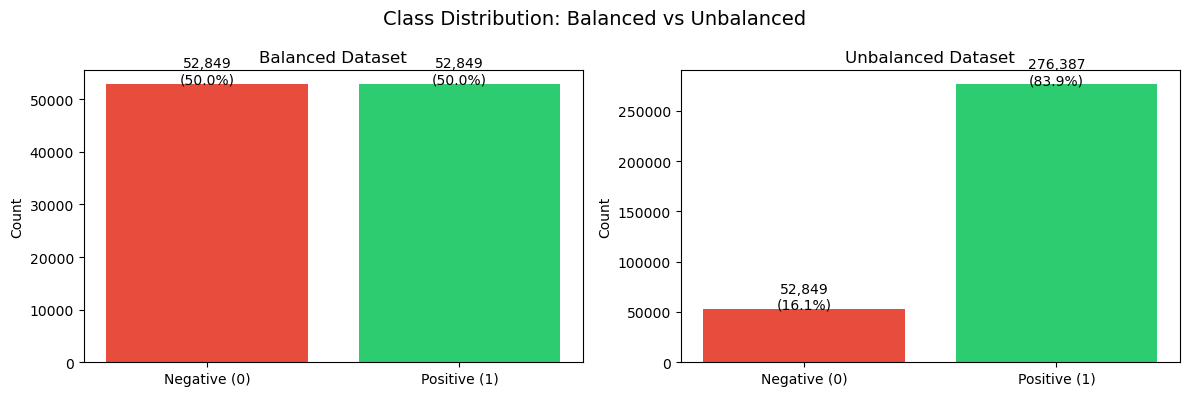


Unbalanced — Negative: 16.1% | Positive: 83.9%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(
    axes,
    [df_bal, df_unbal],
    ["Balanced Dataset", "Unbalanced Dataset"]
):
    counts = df["label"].value_counts().sort_index()
    ax.bar(["Negative (0)", "Positive (1)"], counts.values, color=["#e74c3c", "#2ecc71"])
    ax.set_title(title)
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 200, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center")

plt.suptitle("Class Distribution: Balanced vs Unbalanced", fontsize=14)
plt.tight_layout()
plt.savefig("../data/class_distribution.png", dpi=150)
plt.show()

# Key insight
neg_ratio = (df_unbal["label"] == 0).sum() / len(df_unbal)
pos_ratio = (df_unbal["label"] == 1).sum() / len(df_unbal)
print(f"\nUnbalanced — Negative: {neg_ratio:.1%} | Positive: {pos_ratio:.1%}")

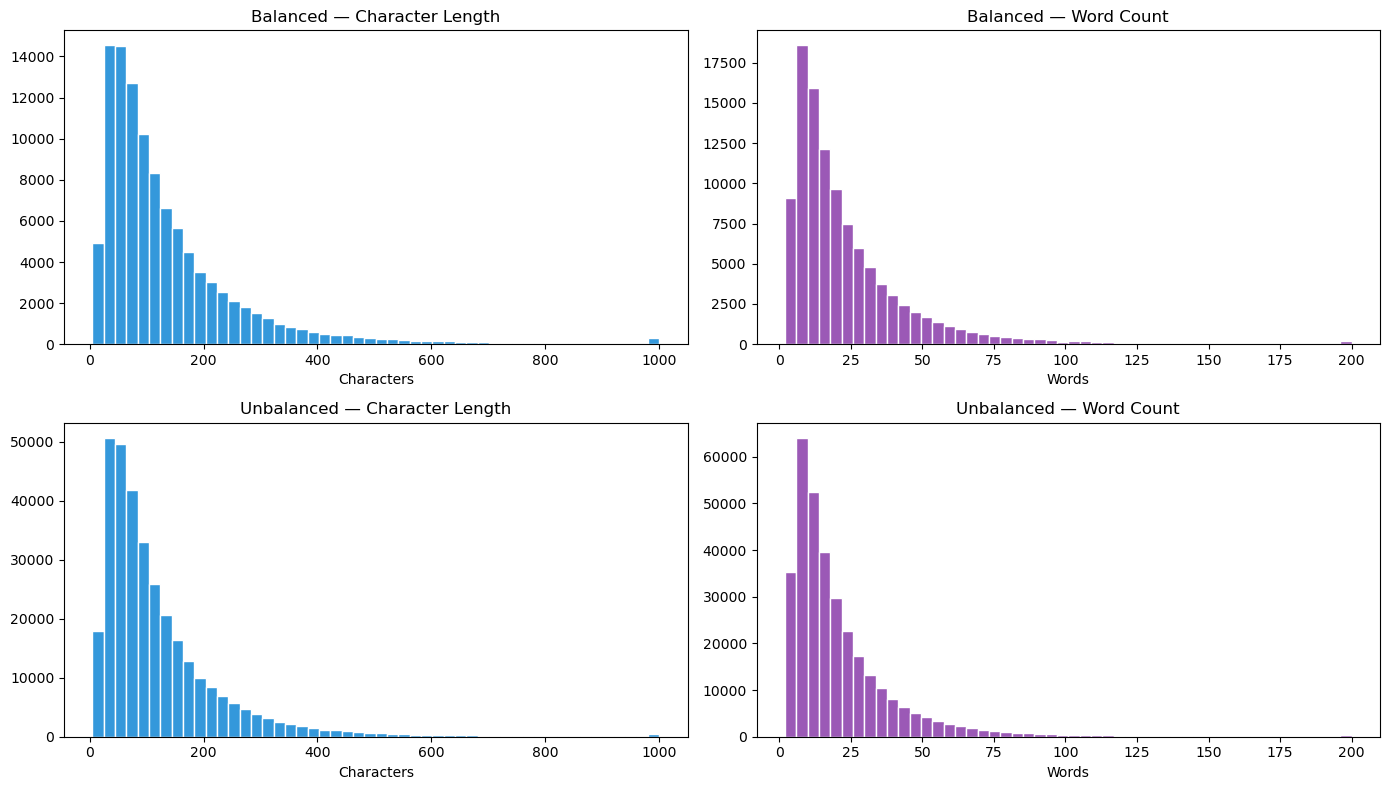


95th percentile word count (balanced): 67
→ Use max_length=87 for AraBERT


In [7]:
df_bal["char_len"]  = df_bal["review"].str.len()
df_bal["word_len"]  = df_bal["review"].str.split().str.len()
df_unbal["char_len"] = df_unbal["review"].str.len()
df_unbal["word_len"] = df_unbal["review"].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (df, title) in enumerate([(df_bal, "Balanced"), (df_unbal, "Unbalanced")]):
    axes[i][0].hist(df["char_len"].clip(upper=1000), bins=50, color="#3498db", edgecolor="white")
    axes[i][0].set_title(f"{title} — Character Length")
    axes[i][0].set_xlabel("Characters")

    axes[i][1].hist(df["word_len"].clip(upper=200), bins=50, color="#9b59b6", edgecolor="white")
    axes[i][1].set_title(f"{title} — Word Count")
    axes[i][1].set_xlabel("Words")

plt.tight_layout()
plt.savefig("../data/length_distribution.png", dpi=150)
plt.show()

# Stats for AraBERT max_length decision
p95_words_bal = df_bal["word_len"].quantile(0.95)
print(f"\n95th percentile word count (balanced): {p95_words_bal:.0f}")
print(f"→ Use max_length={min(int(p95_words_bal * 1.3), 256)} for AraBERT")


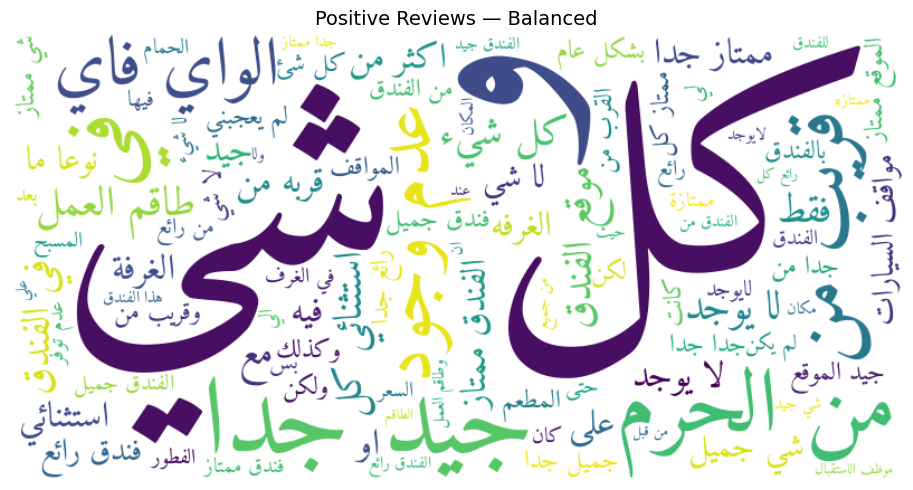

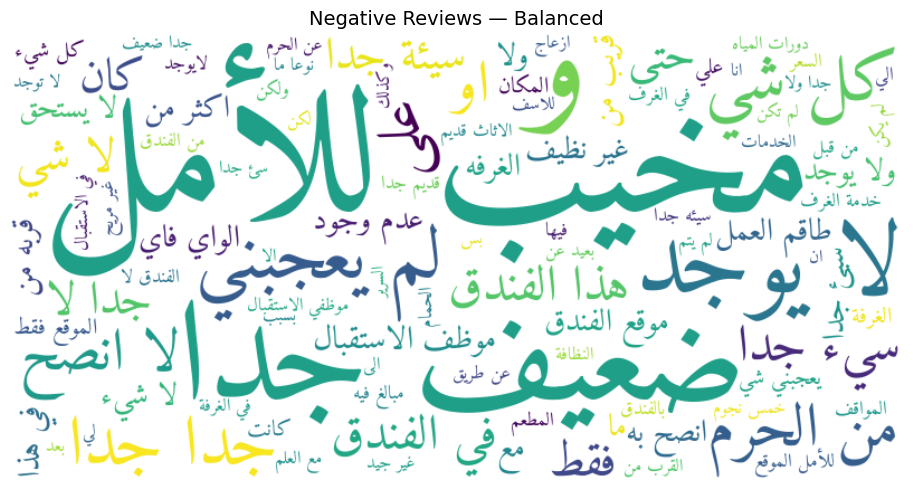

=== 5 Positive Reviews (Balanced) ===
  • “تجربة جميله”. النظافة و حسن الاستقبال والراحة. الفطور جدا سيئ مالح جدا وغير متنوعالكفي شوب والمطعم جدا محدود

  • رائع. التصميم جدا رائع وطريقة توزيع الاضاءة واتساع الغرف شي جدا جميل .. موقعه جدا بعيد عن وسط الدمام لا يوجد جلسات عائلية في المطعم

  • “فندق جميل جدا جدا”. كل شي. لا شي

  • “مشاوير ياقلب العنا مشاوييييير”. النظافه وكونه جديد. البعد عن كل شئ  وكذلك البطء في الرد على الهاتف وتلبية تلطلبات

  • جيد جداً. . الانترنت جدا ضعيف

=== 5 Negative Reviews (Balanced) ===
  • “اام بعجبني”. غير مريح وسعر مرتفع. اسعر مرتفع  وغير مريح  وصور ااموقع غير الحقيقه

  • ضعيف جداً. الرائحه كريهه جدا و لا يصلح للسكن. الرائحه كريهه جدا و لا يصلح للسكن

  • ضعيف. لا شيء. المبنى قديم الموقع صعب الدخول اليه و الخروج منه ( حاره شوارعها ضيقه و مزدحمة)طاقم لا يتحلى باحترام الزبون ان لم تجسد فعل ترى ذلك طريقة تعاملهم

  • “سيء جداً”. لم يعجبني شيء. التكييف والخدمه وازعاج الزوار

  • مخيب للأمل. قرب المكان من الحرم و أسعار قائمة الطعام .. لم يكن الفندق ٥ نجوم ك

In [10]:
# NOTE: Download Amiri font .ttf and set font_path for proper Arabic rendering
# https://fonts.google.com/specimen/Amiri

import matplotlib.pyplot as plt
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display

font_path = "C:/Users/co.magic/Desktop/arabic-sentiment-hard/arabic-sentiment-hard/static/fonts/Amiri-Regular.ttf"

def make_wordcloud(text_series, title, font_path=font_path):
    text = " ".join(text_series.dropna().astype(str).tolist())
    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)
    wc = WordCloud(width=800, height=400, background_color="white",
                   font_path=font_path, max_words=100).generate(bidi_text)
    plt.figure(figsize=(12,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()


# Run on balanced only (unbalanced used for testing — don't analyze too deeply)
make_wordcloud(df_bal[df_bal["label"] == 1]["review"], "Positive Reviews — Balanced")
make_wordcloud(df_bal[df_bal["label"] == 0]["review"], "Negative Reviews — Balanced")

# ── Cell 7: Sample Reviews ────────────────────────────────────
print("=== 5 Positive Reviews (Balanced) ===")
for r in df_bal[df_bal["label"] == 1]["review"].sample(5, random_state=42):
    print(f"  • {r[:200]}\n")

print("=== 5 Negative Reviews (Balanced) ===")
for r in df_bal[df_bal["label"] == 0]["review"].sample(5, random_state=42):
    print(f"  • {r[:200]}\n")

In [11]:
print("""
EDA Summary
───────────
Balanced dataset:   {bal_size:,} reviews ({bal_pos:.1%} positive)
Unbalanced dataset: {unbal_size:,} reviews ({unbal_pos:.1%} positive)

95th percentile word count: {p95:.0f} words
→ AraBERT max_length recommendation: {max_len}

Dialect: Primarily Gulf Arabic (UAE/Saudi) — dialectal normalization
         is limited; model must handle this naturally.
""".format(
    bal_size=len(df_bal),
    bal_pos=(df_bal["label"]==1).mean(),
    unbal_size=len(df_unbal),
    unbal_pos=(df_unbal["label"]==1).mean(),
    p95=p95_words_bal,
    max_len=min(int(p95_words_bal * 1.3), 256)
))


EDA Summary
───────────
Balanced dataset:   105,698 reviews (50.0% positive)
Unbalanced dataset: 329,236 reviews (83.9% positive)

95th percentile word count: 67 words
→ AraBERT max_length recommendation: 87

Dialect: Primarily Gulf Arabic (UAE/Saudi) — dialectal normalization
         is limited; model must handle this naturally.

